# Sentiment Analysis using ML models

Step 1: Import Libraries

In [77]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Text processing
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

Step 2: Load the Dataset

In [78]:
# Load the CSV file
df = pd.read_csv("sentimentdataset.csv")

# Display first few rows
df.head()

,Text,Emotion,Sentiment
0,I feel intrigued today.,Curiosity,Neutral
1,thank you to my coach for your patience,Gratitude,Positive
2,Can't believe how abysmal the documentary turn...,Disappointment,Negative
3,"All is calm, sipping tea by the window.",Contentment,Positive
4,feeling absolutely delighted that my friend re...,Joy,Positive


Step 3: Initial Data Inspection

In [79]:
# Dataset info
print("\n Dataset Information:")
df.info()


 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11558 entries, 0 to 11557
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       11558 non-null  object
 1   Emotion    11558 non-null  object
 2   Sentiment  11558 non-null  object
dtypes: object(3)
memory usage: 271.0+ KB


In [80]:
# Check missing values
print("\n Missing Values:")
print(df.isnull().sum())


 Missing Values:
Text         0
Emotion      0
Sentiment    0
dtype: int64


In [81]:
# Quick statistical summary for numerical columns
print("\n Numerical Summary:")
print(df.describe())


 Numerical Summary:
                           Text Emotion Sentiment
count                     11558   11558     11558
unique                    11558      16         3
top     I feel intrigued today.     Joy  Positive
freq                          1    2787      4393


In [82]:
# Check unique sentiment labels
print("\n Sentiment Classes:")
print(df['Sentiment'].value_counts())


 Sentiment Classes:
Sentiment
Positive    4393
Negative    4272
Neutral     2893
Name: count, dtype: int64


Step 4: Exploratory Data Analysis(EDA)

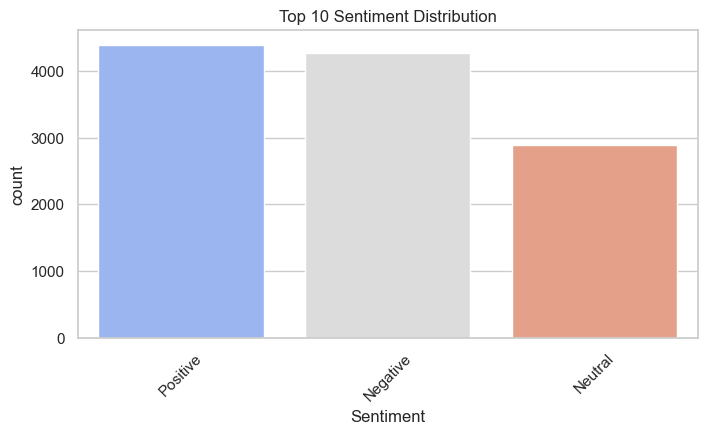

In [83]:
# Get top 10 sentiments by count
top_sentiments = df['Sentiment'].value_counts().nlargest(10).index
df_top = df[df['Sentiment'].isin(top_sentiments)]

# 4.1 Sentiment Distribution
plt.figure(figsize=(8,4))
sns.countplot(data=df_top, x='Sentiment', palette='coolwarm', order=top_sentiments)
plt.title('Top 10 Sentiment Distribution')
plt.xticks(rotation=45)
plt.show()

Step 5: Text Cleaning & Preprocessing

In [84]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"#\w+", "", text)           # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)       # keep only letters
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text.strip()

df['Clean_Text'] = df['Text'].apply(clean_text)
df[['Text', 'Clean_Text']].head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\agamn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Text,Clean_Text
0,I feel intrigued today.,feel intrigued today
1,thank you to my coach for your patience,thank coach patience
2,Can't believe how abysmal the documentary turn...,cant believe abysmal documentary turned
3,"All is calm, sipping tea by the window.",calm sipping tea window
4,feeling absolutely delighted that my friend re...,feeling absolutely delighted friend returned h...
5,The campsite made my day clunkier. #thoughts,campsite made day clunkier
6,It was effective.,effective
7,"Got the keyboard yesterday, it stopped respond...",got keyboard yesterday stopped responding
8,"Overall, the novel was pathetic.",overall novel pathetic
9,I can see the good and the bad in graduating.,see good bad graduating


Step 6: Text Analysis

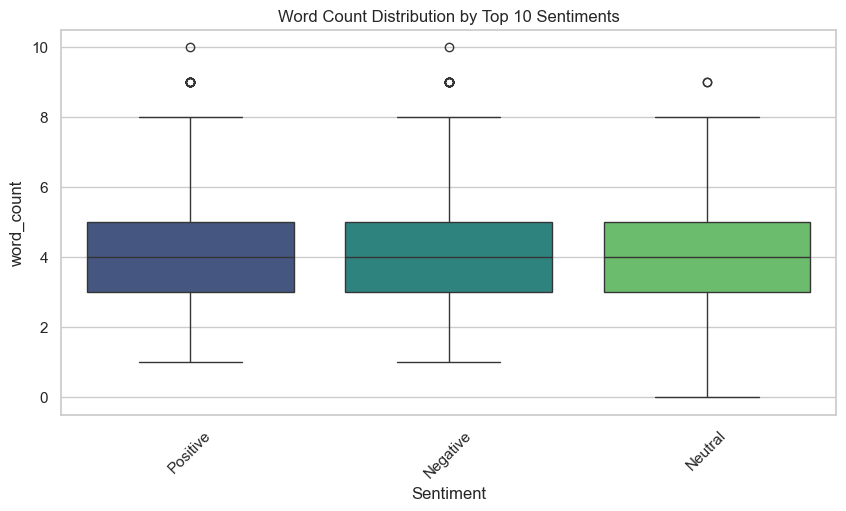


Top words for Positive:


,Word,Frequency
0,cant,367
1,today,326
2,im,303
3,believe,256
4,day,244



Top words for Negative:


,Word,Frequency
0,im,373
1,today,322
2,cant,315
3,honestly,243
4,believe,222



Top words for Neutral:


,Word,Frequency
0,im,135
1,new,134
2,update,126
3,next,103
4,office,101


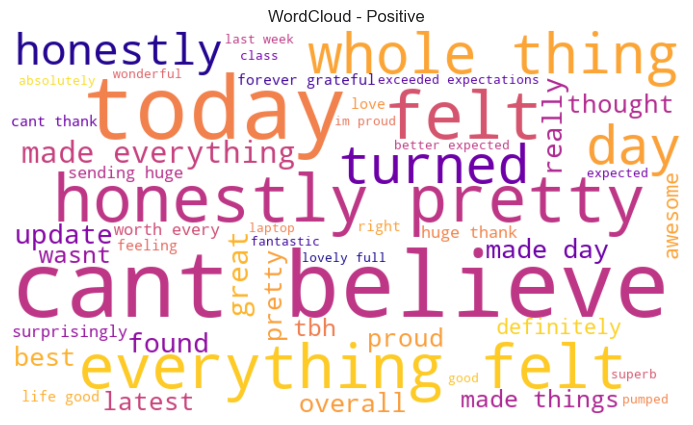

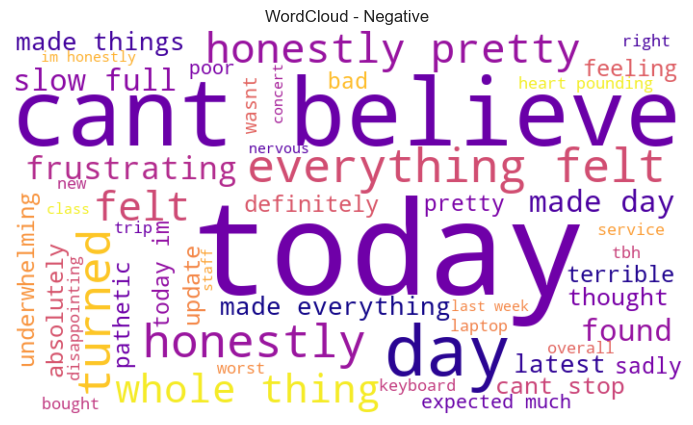

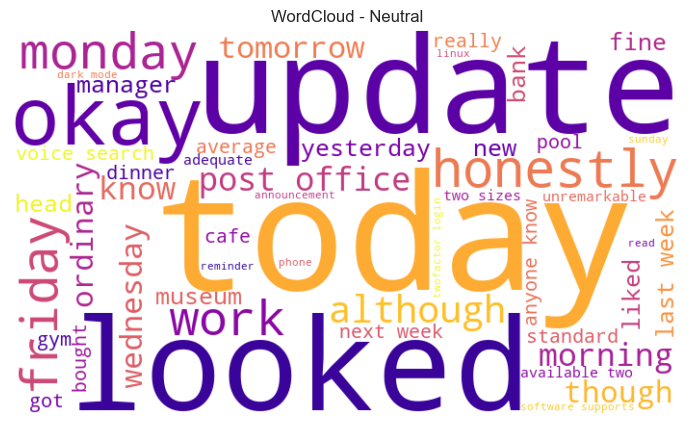

In [85]:
# Select top 10 most frequent sentiments
top_sentiments = df['Sentiment'].value_counts().nlargest(10).index
df_top = df[df['Sentiment'].isin(top_sentiments)]

# Average Word Count per Sentiment (Top 10)
df_top['word_count'] = df_top['Clean_Text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.boxplot(data=df_top, x='Sentiment', y='word_count', palette='viridis', order=top_sentiments)
plt.title('Word Count Distribution by Top 10 Sentiments')
plt.xticks(rotation=45)
plt.show()

# Most Common Words per Sentiment (Top 10 sentiments, top 5 words each)
def most_common_words(sentiment, n=5):
    words = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text']).split()
    common = Counter(words).most_common(n)
    return pd.DataFrame(common, columns=['Word','Frequency'])

for s in top_sentiments:
    print(f"\nTop words for {s}:")
    display(most_common_words(s, n=5))  # only top 5 words


# WordClouds for Top 10 Sentiments
for sentiment in top_sentiments:
    text = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text'])
    wc = WordCloud(width=700, height=400, background_color='white', colormap='plasma', max_words=50).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {sentiment}")
    plt.show()

Step 7: Feature Extraction

In [86]:
# Combine rare classes with <2 samples into 'Other'
# Combine rare classes with <2 samples into 'Other'
counts = df['Sentiment'].value_counts()
rare_classes = counts[counts < 2].index
df['Sentiment'] = df['Sentiment'].replace(rare_classes, 'Other')

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95
)
X = tfidf.fit_transform(df['Clean_Text'])
y = df['Sentiment']

# Train/Test Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (9246, 8257) Test shape: (2312, 8257)


Step 8: Model Traning and Comparision

In [87]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 0.9554
Naive Bayes Accuracy: 0.9420
Linear SVM Accuracy: 0.9585
Random Forest Accuracy: 0.8789


Step 9: Visual Comparision of Model Accuracies

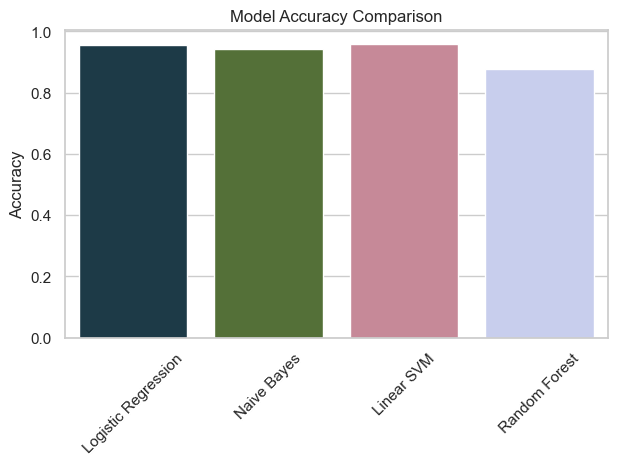


 Best Performing Model: Linear SVM (95.85% accuracy)


In [88]:
plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='cubehelix')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

best_model_name = max(results, key=results.get)
print(f"\n Best Performing Model: {best_model_name} ({results[best_model_name]:.2%} accuracy)")

Step 10: Detailed Evaluation of Best Model

In [89]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.95       854
     Neutral       0.98      0.94      0.96       579
    Positive       0.95      0.97      0.96       879

    accuracy                           0.96      2312
   macro avg       0.96      0.96      0.96      2312
weighted avg       0.96      0.96      0.96      2312



Step 11: Save Best Model and Vectorizer

In [90]:
joblib.dump(best_model, "best_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n Model and TF-IDF Vectorizer saved successfully!")


 Model and TF-IDF Vectorizer saved successfully!


Step 12: Predict Sentiment on New Text

In [91]:
def predict_sentiment(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])
    pred = best_model.predict(vec)[0]
    return pred

# Example predictions
samples = [
    "I love this new feature!",
    "The service was awful and slow.",
    "It's okay, not too bad but not great either."
]

for s in samples:
    print(f"Text: {s} → Sentiment: {predict_sentiment(s)}")


Text: I love this new feature! → Sentiment: Positive
Text: The service was awful and slow. → Sentiment: Negative
Text: It's okay, not too bad but not great either. → Sentiment: Neutral


Step 13: Export Cleaned Dataset

In [92]:
df.to_csv("cleaned_sentiment_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


Step 14: Train Emotion Model (16 emotions)

In [93]:
y_emotion = df['Emotion']

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X, y_emotion, test_size=0.2, random_state=42, stratify=y_emotion
)

emotion_model = LinearSVC()
emotion_model.fit(Xe_train, ye_train)

ye_pred = emotion_model.predict(Xe_test)
print(f"Emotion Model Accuracy: {accuracy_score(ye_test, ye_pred):.4f}")
print(classification_report(ye_test, ye_pred))

joblib.dump(emotion_model, "emotion_model.pkl")
print("Emotion model saved successfully!")

Emotion Model Accuracy: 0.9567
                precision    recall  f1-score   support

   Ambivalence       0.96      0.84      0.90       141
         Anger       0.98      0.98      0.98       102
   Contentment       1.00      0.89      0.94        54
     Curiosity       0.97      0.97      0.97        79
Disappointment       0.95      0.93      0.94       481
       Disgust       1.00      0.98      0.99        61
    Excitement       1.00      1.00      1.00        60
          Fear       1.00      0.99      0.99        74
     Gratitude       1.00      0.95      0.98        63
          Hope       0.98      0.96      0.97        47
           Joy       0.90      0.97      0.93       558
    Loneliness       1.00      0.92      0.96        48
          Love       1.00      1.00      1.00        51
       Neutral       0.99      0.99      0.99       359
         Pride       1.00      1.00      1.00        46
       Sadness       0.96      0.97      0.96        88

      accuracy 

Step 15: Predict Emotion and Polarity on New Text

In [94]:
def predict_emotion(text):
    vec = tfidf.transform([clean_text(text)])
    return emotion_model.predict(vec)[0], best_model.predict(vec)[0]

for s in ["I am so scared of the dark tonight",
          "thank you so much for helping me, I really appreciate it"]:
    emotion, polarity = predict_emotion(s)
    print(f"Text: {s}\n   → Emotion: {emotion} | Polarity: {polarity}\n")

Text: I am so scared of the dark tonight
   → Emotion: Fear | Polarity: Negative

Text: thank you so much for helping me, I really appreciate it
   → Emotion: Gratitude | Polarity: Positive

